## 06: Demand Forecasting

### Introduction

This notebook implements the **Modeling** phase of the CRISP-DM workflow for the Divvy
bike-share project. It picks up where `05_exploratory_analysis.ipynb` leaves off — using the
quality-checked warehouse from `02_database_design.ipynb` / `03_etl_pipeline.ipynb`
and validated in `04_data_quality_assessment.ipynb` — and builds a **time-series forecast of
daily ride demand**.

It answers: how many rides should we expect system-wide and per rider segment (member vs.
casual) over the next `FORECAST_HORIZON_DAYS`, and how much better is a proper time-series
model than a naive guess?

Scope: system-wide daily ride counts, plus a member/casual breakdown. ETL-flagged anomalies are
excluded, matching the population used in notebook 05. Station-level demand (for rebalancing) is
left as a follow-up notebook, since it needs a different unit of analysis (station x day) and a
much larger, sparser series per station.

**The pipeline:**

1. **Builds** a gap-filled daily ride-count series straight from the warehouse, split system-wide
   and by rider segment.
2. **Diagnoses** the series with an Augmented Dickey-Fuller test, a trend/seasonal/residual
   decomposition, and ACF/PACF plots.
3. **Benchmarks** two naive "no-model" forecasts as a sanity floor.
4. **Fits and fairly compares** a SARIMAX model and a Prophet model on the same held-out window,
   selecting the stronger one by RMSE/MAE/MAPE.
5. **Refits** the winning model type on the full history and projects it forward, both
   system-wide and per rider segment, with uncertainty intervals.
6. **Publishes a structured report** in three formats (Markdown, JSON, CSV), so the forecast can
   be read by a person, consumed by another script, or dropped straight into a BI tool.

**Why this matters:** producing a single forecast is easy; producing a
*trustworthy* one requires proving it beats a naive guess, comparing more than one modeling
approach instead of assuming one is automatically best, and being explicit about the model's
uncertainty rather than presenting a falsely precise number. This notebook demonstrates that
discipline end to end — the same rigor expected of a data scientist or ML engineer building a
production demand-forecasting pipeline.

**Skills demonstrated:** SQL/warehouse integration, time-series diagnostics and statistical
testing, classical (SARIMAX) and modern (Prophet) forecasting techniques, rigorous model
evaluation and selection, forecast-uncertainty communication, customer segmentation, and
automated multi-format reporting.

#### Models compared
1. Naive (last value)
2. Seasonal naive (last week)
3. SARIMAX(1,1,1)(1,1,1,7)
4. Prophet (weekly + yearly seasonality)

#### Deliverables
- **Forecast Report** — a structured Markdown/JSON/CSV report with the holdout comparison, chosen
  model, and production forecast
- **System-wide forecast** — a `FORECAST_HORIZON_DAYS`-day forward projection with a confidence
  interval
- **Segment forecast** — independent member vs. casual projections


### Imports, Configuration, and Helpers

Brings in everything the forecast needs: `pandas`/`numpy` for the data handling and array math
behind every model, `matplotlib` for the charts produced throughout, `statsmodels` for the
classical time-series tests and the SARIMAX model itself, and Meta's open-source `Prophet`
library as a second, independent forecasting approach. The `config` module keeps database
credentials in an external file rather than hardcoded in the notebook — the same secure-credential
pattern used across the rest of this project (`02_database_design.ipynb`–
`05_exploratory_analysis.ipynb`).

Below the imports, a short configuration block centralizes every constant this forecast depends
on so nothing is a "magic number" buried inside a model call: where the report files get written,
how many days to hold back for testing (`TEST_HORIZON_DAYS`) versus how many days to forecast
into the future (`FORECAST_HORIZON_DAYS`), the length of the weekly seasonal cycle
(`SEASONAL_PERIOD = 7`), and the width of the plotted confidence interval (`CONFIDENCE_LEVEL`).
Defining these once, up front, means every model fit later in the notebook uses the exact same
assumptions, and anyone reviewing the notebook can see those assumptions without hunting through
the code.

**Skills demonstrated:** secure credential handling, configuration-driven design,
reproducible-research setup, working with time-series and forecasting libraries (`statsmodels`,
`Prophet`).


In [1]:
import os
import json
import warnings
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from IPython.display import Markdown, display
import config
import cmdstanpy
#cmdstanpy.install_cmdstan(overwrite=True, compiler=True)

#warnings.filterwarnings("ignore")

# Project folder (comprehensive_divvy_bike_sharing_analytics), one level up from notebooks/
PROJECT_FOLDER = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
REPORTS_FOLDER = os.path.join(PROJECT_FOLDER, "reports", "demand_forecasting_reports")
os.makedirs(REPORTS_FOLDER, exist_ok=True)

SCHEMA = "divvy"
EXCLUDE_FLAGGED_ANOMALIES = True   # matches notebook 05's population

# Forecasting configuration
TEST_HORIZON_DAYS = 28        # holdout window used to score competing models
FORECAST_HORIZON_DAYS = 28    # length of the final production forecast
SEASONAL_PERIOD = 7           # weekly seasonality (day-of-week ridership pattern)
CONFIDENCE_LEVEL = 0.80       # width of the plotted forecast interval

RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat(timespec="seconds")
print(f"Reports will be written to: {REPORTS_FOLDER}")
print(f"Run timestamp (UTC): {RUN_TIMESTAMP}")

C:\Projects\comprehensive_divvy_bike_sharing_analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Reports will be written to: C:\Projects\comprehensive_divvy_bike_sharing_analytics\reports\demand_forecasting_reports
Run timestamp (UTC): 2026-09-13T22:41:07+00:00


### Database Connection

Two small helper functions the rest of the notebook builds on. `run_query()` opens a connection
to the `divvy_db` warehouse using the same credential pattern as the earlier notebooks, runs a
SQL query into a pandas DataFrame, and — critically — always closes the connection in a `finally`
block even if the query raises an error, so a failed query never leaves a dangling database
connection. `savefig()` wraps `matplotlib`'s save logic so every chart in the notebook lands in
the same reports folder at a consistent, print-ready resolution. A final line builds the SQL
filter (`ANOMALY_FILTER`) that excludes trips already flagged as data-quality anomalies in
`03_etl_pipeline.ipynb`/`04_data_quality_assessment.ipynb`, so the forecast is built
on the same clean population used in the exploratory analysis.

**Skills demonstrated:** SQL/PostgreSQL integration with Python, defensive error handling and
resource cleanup, reusable helper-function design, consistency with an upstream data-quality
process.


In [2]:
def run_query(sql, params=None):
    try:
        conn = psycopg2.connect(**config.config_divvy())
        return pd.read_sql_query(sql, conn, params=params)
    except Exception as error:
        raise ConnectionError(f"Could not query divvy_db: {error}") from error
    finally:
        if "conn" in locals():
            conn.close()

def savefig(filename):
    path = os.path.join(REPORTS_FOLDER, filename)
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("Saved:", path)

ANOMALY_FILTER = "COALESCE(f.is_anomalous, FALSE) = FALSE" if EXCLUDE_FLAGGED_ANOMALIES else "TRUE"
print("Population filter:", ANOMALY_FILTER)

Population filter: COALESCE(f.is_anomalous, FALSE) = FALSE


### Build the Daily Demand Series

Pulls one row per calendar day x rider segment from `fact_trip`, joined against `dim_date` and
`dim_member_type`, to get a daily ride count split by member vs. casual rider. Because a day with
zero trips would otherwise simply be missing from the query results rather than showing up as an
explicit zero, the series is reindexed onto the full calendar range (`full_range`) before
anything else happens — a gap here would silently distort the weekly seasonality that every model
in this notebook depends on. The result is two views of the same underlying data: `system`, a
single system-wide daily total used for the primary forecast, and `segments`, a member/casual
pivot used for the segment-level forecast later on.

**Skills demonstrated:** SQL joins across a star-schema warehouse, time-series data preparation,
correctly handling missing data (explicit zero-filling vs. silent gaps), pandas reshaping
(`pivot`, `reindex`, `groupby`).


In [3]:
daily = run_query(f'''
    SELECT d.full_date, mt.member_casual, COUNT(*) AS ride_count
    FROM {SCHEMA}.fact_trip f
    JOIN {SCHEMA}.dim_date d ON f.start_date_key = d.date_key
    JOIN {SCHEMA}.dim_member_type mt ON f.member_type_key = mt.member_type_key
    WHERE {ANOMALY_FILTER}
    GROUP BY d.full_date, mt.member_casual
    ORDER BY d.full_date
''')
daily["full_date"] = pd.to_datetime(daily["full_date"])
print(f"{len(daily):,} (date x segment) rows | {daily.full_date.min().date()} -> {daily.full_date.max().date()}")

full_range = pd.date_range(daily.full_date.min(), daily.full_date.max(), freq="D")

# System-wide series (used for the primary forecast)
system = (
    daily.groupby("full_date")["ride_count"].sum()
    .reindex(full_range, fill_value=0)
    .rename("ride_count")
)
system.index.name = "full_date"

# Member vs. casual series (used for the segment-level forecast in Step 9)
segments = (
    daily.pivot(index="full_date", columns="member_casual", values="ride_count")
    .reindex(full_range, fill_value=0)
)

n_zero_fill = int((system.reindex(full_range).fillna(0) == 0).sum())
print(f"Calendar days in series: {len(system)} | zero-ride days after gap-fill: {n_zero_fill}")
display(system.describe().to_frame("system_daily_rides"))
segments.tail()

C:\Users\shk\AppData\Local\Temp\ipykernel_8976\3312801164.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


1,948 (date x segment) rows | 2024-01-01 -> 2026-08-31
Calendar days in series: 974 | zero-ride days after gap-fill: 0


,system_daily_rides
count,974.000000
mean,15673.706366
std,8740.548565
min,429.000000
25%,7762.500000
50%,15549.500000
75%,23274.250000
max,39342.000000


member_casual,casual,member
2026-08-27,10535,20013
2026-08-28,13617,18860
2026-08-29,15501,16327
2026-08-30,7993,10807
2026-08-31,5032,11962


### Time Series Diagnostics

Checks the assumptions every model below relies on before any model is actually fit: is the
daily series stationary or trending (Augmented Dickey-Fuller test), what do the trend,
weekly-seasonal, and residual components look like once decomposed, and do the autocorrelation
plots suggest the specific AR/MA/seasonal lags used in the SARIMAX model two steps later?
Everything in this section is diagnostic only — nothing here changes the series itself, it only
informs the modeling choices that follow.

**Skills demonstrated:** statistical diagnostic reasoning applied before committing to a modeling
approach, rather than fitting a model first and rationalizing the choice afterward.

#### Stationarity and Seasonal Decomposition

Runs the Augmented Dickey-Fuller test — a standard statistical test for whether a time series is
trending over time (non-stationary) versus fluctuating around a stable mean (stationary) — and
prints a plain-language interpretation of the p-value alongside the raw statistic. It then
decomposes the daily series into three components using `seasonal_decompose`: the long-term
trend, the repeating weekly seasonal pattern, and the residual noise left over once both are
removed. This is purely diagnostic: nothing here changes the underlying series, but the result
directly justifies the differencing and seasonal terms chosen for the SARIMAX model a few steps
later.

**Skills demonstrated:** applied statistical hypothesis testing, time-series decomposition,
translating statistical output into a concrete modeling decision.


Augmented Dickey-Fuller: stat=-1.675, p-value=0.4439
-> non-stationary at 5%; SARIMAX's differencing (d=1) should compensate


C:\Users\shk\AppData\Local\Temp\ipykernel_8976\1329062580.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(system.dropna())


Saved: C:\Projects\comprehensive_divvy_bike_sharing_analytics\reports\demand_forecasting_reports\01_decomposition.png


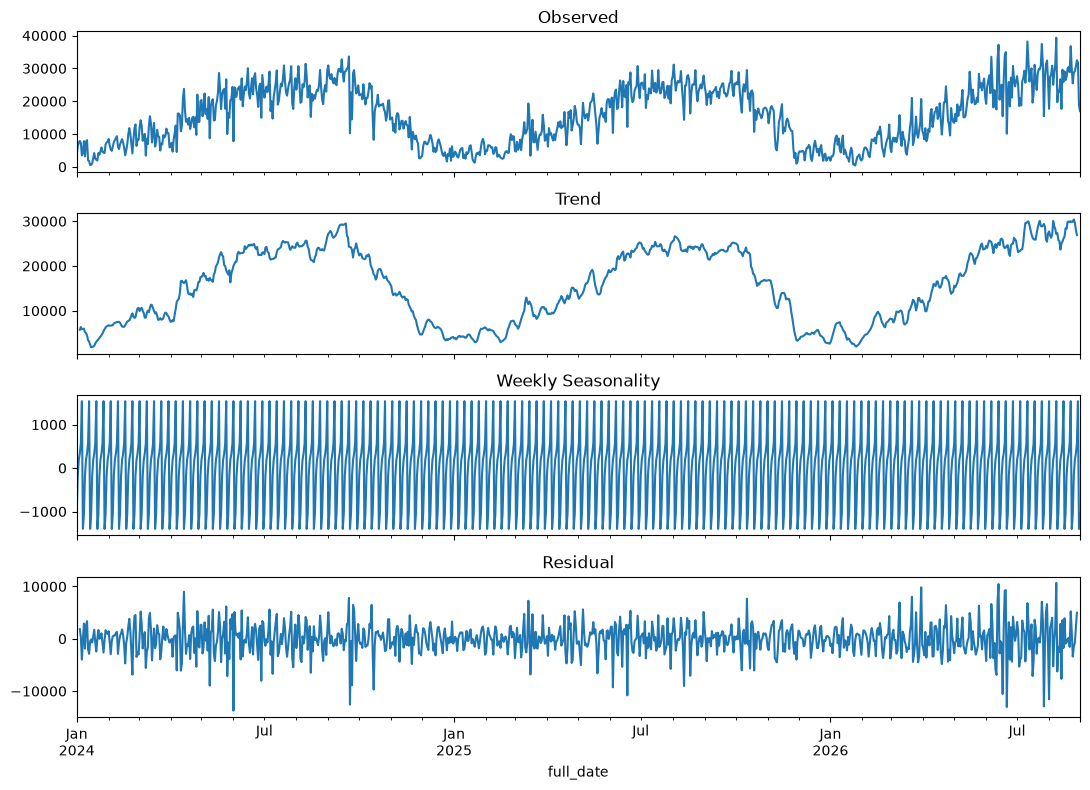

In [4]:
adf_stat, adf_p, *_ = adfuller(system.dropna())
print(f"Augmented Dickey-Fuller: stat={adf_stat:.3f}, p-value={adf_p:.4f}")
print("-> stationary (reject unit root) at 5%" if adf_p < 0.05 else "-> non-stationary at 5%; SARIMAX's differencing (d=1) should compensate")

decomposition = seasonal_decompose(system, model="additive", period=SEASONAL_PERIOD)
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend")
decomposition.seasonal.plot(ax=axes[2], title="Weekly Seasonality")
decomposition.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout()
savefig("01_decomposition.png")
plt.show()

#### Autocorrelation Diagnostics (ACF/PACF)

Plots the autocorrelation function (ACF) and partial autocorrelation function (PACF) side by
side, showing how strongly today's ridership correlates with ridership from 1, 2, 3+ days — and
full weeks — earlier. These are the standard charts practitioners use to choose the specific AR,
MA, and seasonal lag settings for a SARIMAX model, so including them here shows the model's
`order`/`seasonal_order` parameters were chosen from evidence in the data rather than by
guesswork.

**Skills demonstrated:** time-series diagnostics, statistical visualization, evidence-based
model-selection reasoning.


Saved: C:\Projects\comprehensive_divvy_bike_sharing_analytics\reports\demand_forecasting_reports\02_acf_pacf.png


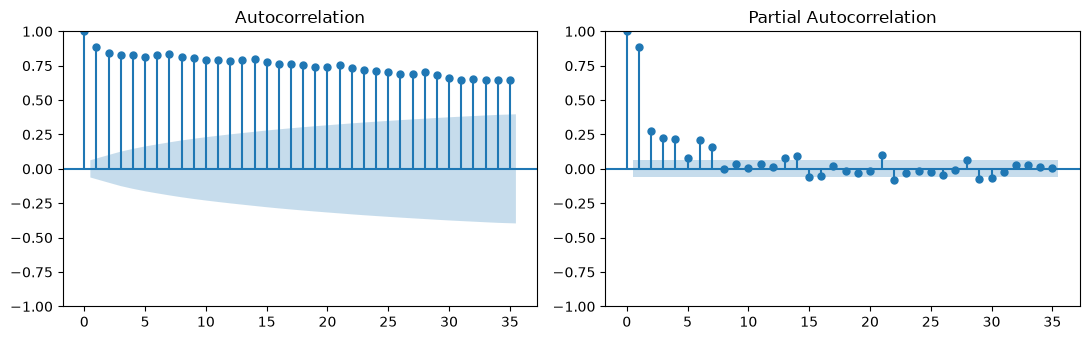

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
plot_acf(system, lags=35, ax=axes[0])
plot_pacf(system, lags=35, ax=axes[1])
plt.tight_layout()
savefig("02_acf_pacf.png")
plt.show()

### Train / Test Split

Splits the historical series into a `train` set (everything except the last
`TEST_HORIZON_DAYS`) and a `test` set (that final window), so every model built in the next
several steps is fit only on `train` and scored against the exact same, never-before-seen `test`
window — the same held-out validation approach used to evaluate any forecasting or machine
learning model honestly. This cell also defines the notebook's shared scoring functions: a
custom `mean_absolute_percentage_error()` (guarding against division by zero on any
zero-demand day) and `evaluate_forecast()`, which bundles MAE, RMSE, and MAPE into one
dictionary. Every model that follows is graded with this exact same function, so the comparison
in the Model Comparison step is a fair, apples-to-apples evaluation.

**Skills demonstrated:** train/test validation methodology for time series, custom
evaluation-metric implementation, safeguarding against edge cases (division by zero) in a
hand-written metric.


In [6]:
train, test = system.iloc[:-TEST_HORIZON_DAYS], system.iloc[-TEST_HORIZON_DAYS:]
print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()} ({len(test)} days)")

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else np.nan

def evaluate_forecast(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return {
        "MAE": float(np.mean(np.abs(y_true - y_pred))),
        "RMSE": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }

results = {}

Train: 2024-01-01 -> 2026-08-03 (946 days)
Test:  2026-08-04 -> 2026-08-31 (28 days)


### Baseline Forecasts

Builds two deliberately simple "no-model" forecasts to serve as a sanity floor before any real
model is trained: **naive**, which just repeats the last observed value for every day of the
test window, and **seasonal naive**, which repeats the same day-of-week pattern from the most
recently observed full week. Both are scored with the same `evaluate_forecast()` function
defined above and stored in the shared `results` dictionary. Any model built afterward — SARIMAX
or Prophet — has to actually beat both of these before its added complexity is worth trusting.

**Skills demonstrated:** benchmarking methodology, critical evaluation of model complexity
versus real predictive value, NumPy array manipulation (`np.repeat`, `np.tile`).


In [7]:
naive_pred = np.repeat(train.iloc[-1], len(test))
results["Naive (last value)"] = evaluate_forecast(test.values, naive_pred)

last_week = train.iloc[-SEASONAL_PERIOD:].values
seasonal_naive_pred = np.tile(last_week, int(np.ceil(len(test) / SEASONAL_PERIOD)))[: len(test)]
results["Seasonal naive (last week)"] = evaluate_forecast(test.values, seasonal_naive_pred)

pd.DataFrame(results).T

,MAE,RMSE,MAPE
Naive (last value),3874.892857,5140.359010,15.979751
Seasonal naive (last week),5908.250000,8037.506216,22.655295


### SARIMAX Model

Fits a SARIMAX(1,1,1)(1,1,1,7) model on the training data — first-order differencing to handle
the trend flagged by the ADF test, plus a seasonal term tuned to the 7-day weekly cycle
confirmed by the decomposition and ACF/PACF plots above. `enforce_stationarity`/
`enforce_invertibility` are relaxed to `False` so the optimizer can still converge on real-world
ridership data that doesn't perfectly satisfy the model's textbook assumptions. The fitted model
then produces a forecast for the test window, complete with a confidence interval, and is scored
using the exact same `evaluate_forecast()` function as the baselines.

**Skills demonstrated:** classical time-series modeling (SARIMA/SARIMAX), translating diagnostic
plots into concrete model hyperparameters, forecasting with uncertainty intervals.


In [8]:
sarimax_fit = SARIMAX(
    train, order=(1, 1, 1), seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

sarimax_forecast = sarimax_fit.get_forecast(steps=len(test))
sarimax_mean = sarimax_forecast.predicted_mean
sarimax_ci = sarimax_forecast.conf_int(alpha=1 - CONFIDENCE_LEVEL)

results["SARIMAX"] = evaluate_forecast(test.values, sarimax_mean.values)
print(sarimax_fit.summary().tables[0])
pd.DataFrame({"SARIMAX": results["SARIMAX"]}).T

                                     SARIMAX Results                                     
Dep. Variable:                        ride_count   No. Observations:                  946
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -8881.260
Date:                           Sun, 13 Sep 2026   AIC                          17772.519
Time:                                   17:41:13   BIC                          17796.690
Sample:                               01-01-2024   HQIC                         17781.738
                                    - 08-03-2026                                         
Covariance Type:                             opg                                         


,MAE,RMSE,MAPE
SARIMAX,3412.389665,4799.560638,14.931914


### Prophet Model

Fits Meta's open-source Prophet library on the same training data as a second, independent
modeling approach — one designed to automatically detect trend changes and weekly/yearly
seasonality with far less manual tuning than SARIMAX requires. Prophet's `yearly_seasonality`
needs roughly two full years of history to be reliable; the model will warn if less is loaded,
which is a genuine limitation worth flagging rather than hiding. The test-period predictions are
pulled out by date and scored with the same `evaluate_forecast()` function used everywhere else
in the notebook, keeping the comparison fair.

**Skills demonstrated:** applied machine learning with a modern forecasting library (Prophet),
awareness of a model's data requirements and limitations, consistent cross-model evaluation.


In [9]:
prophet_train = train.reset_index().rename(columns={"full_date": "ds", "ride_count": "y"})
prophet_model = Prophet(
    weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False,
    interval_width=CONFIDENCE_LEVEL,
)
prophet_model.fit(prophet_train)
#prophet_model.fit(prophet_train, show_console=True)

future = prophet_model.make_future_dataframe(periods=len(test), freq="D")
prophet_forecast = prophet_model.predict(future)
prophet_test_pred = prophet_forecast.set_index("ds").loc[test.index, "yhat"]

results["Prophet"] = evaluate_forecast(test.values, prophet_test_pred.values)
pd.DataFrame({"Prophet": results["Prophet"]}).T

17:41:14 - cmdstanpy - INFO - Chain [1] start processing
17:41:14 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE,MAPE
Prophet,3887.356254,4798.793911,15.276369


### Model Comparison & Selection

Combines every model's held-out scores (two baselines, SARIMAX, and Prophet) into a single
table, ranks them by RMSE, and highlights the best score in each column so the winner is obvious
at a glance. It also plots all four forecasts against what actually happened over the test
window, which makes the practical difference between "a good forecast" and "a
slightly-better-than-naive forecast" visible in a way a table of numbers alone can't. The
selected `best_model_name` — chosen on evidence, not assumption — is what drives every step from
here forward.

**Skills demonstrated:** data-driven model selection, comparative data visualization,
communicating quantitative model performance to a non-technical audience.


,MAE,RMSE,MAPE
Prophet,3887.356254,4798.793911,15.276369
SARIMAX,3412.389665,4799.560638,14.931914
Naive (last value),3874.892857,5140.359010,15.979751
Seasonal naive (last week),5908.250000,8037.506216,22.655295


Best model on the 28-day holdout: Prophet
Saved: C:\Projects\comprehensive_divvy_bike_sharing_analytics\reports\demand_forecasting_reports\03_holdout_comparison.png


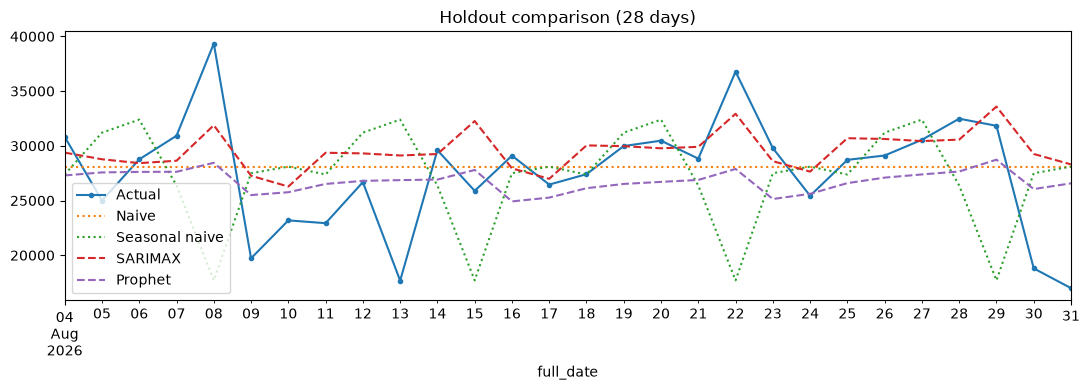

In [10]:
comparison = pd.DataFrame(results).T.sort_values("RMSE")
best_model_name = comparison.index[0]

display(comparison.style.highlight_min(subset=["MAE", "RMSE", "MAPE"], color="#d6f5d6"))
print(f"Best model on the {TEST_HORIZON_DAYS}-day holdout: {best_model_name}")

fig, ax = plt.subplots(figsize=(11, 4))
test.plot(ax=ax, label="Actual", marker="o", markersize=3)
pd.Series(naive_pred, index=test.index).plot(ax=ax, label="Naive", linestyle=":")
pd.Series(seasonal_naive_pred, index=test.index).plot(ax=ax, label="Seasonal naive", linestyle=":")
sarimax_mean.plot(ax=ax, label="SARIMAX", linestyle="--")
prophet_test_pred.plot(ax=ax, label="Prophet", linestyle="--")
ax.legend()
ax.set_title(f"Holdout comparison ({TEST_HORIZON_DAYS} days)")
plt.tight_layout()
savefig("03_holdout_comparison.png")
plt.show()

### Refit on Full History and Forecast Forward

Takes whichever model type won the comparison and refits it on the **entire** available history
— train and test combined — since more data generally produces a better final model, and the
held-out split has already done its job of proving the model works. It then projects
`FORECAST_HORIZON_DAYS` days beyond the last loaded date, clips the forecast at zero (ride counts
can't be negative), and plots the result with a shaded confidence band so the forecast's
uncertainty is visible rather than presented as a single falsely-precise number. The numeric
forecast, along with its lower/upper bounds, is saved to `forecast_table` for the report
generated at the end of the notebook.

**Skills demonstrated:** production-style model refitting, forecast-uncertainty communication,
defensive post-processing (clipping impossible negative values), translating a statistical model
into a business-usable output.


17:41:15 - cmdstanpy - INFO - Chain [1] start processing
17:41:15 - cmdstanpy - INFO - Chain [1] done processing


Saved: C:\Projects\comprehensive_divvy_bike_sharing_analytics\reports\demand_forecasting_reports\04_forecast.png


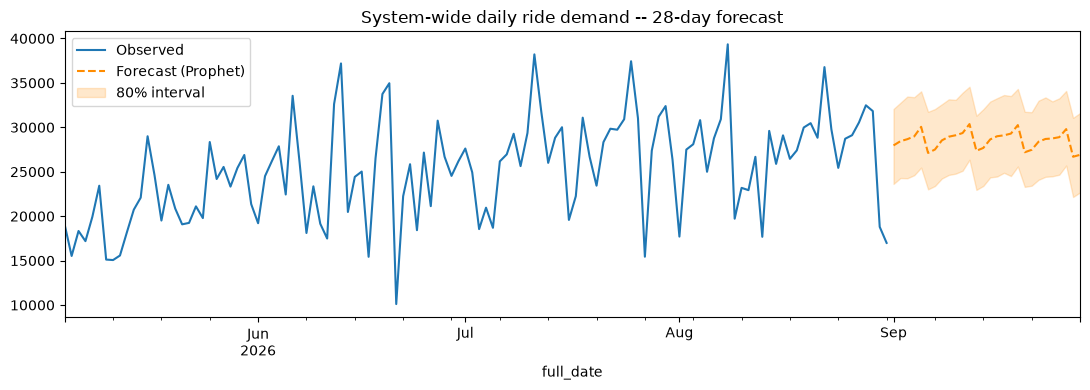

,forecast,lower,upper
2026-09-01,27963.474957,23626.618748,32059.075941
2026-09-02,28440.994124,24293.440213,32763.255281
2026-09-03,28666.575372,24267.902118,33462.637802
2026-09-04,28981.418491,24610.793054,33391.134027
2026-09-05,30058.021804,25464.641953,34052.521554


In [11]:
future_index = pd.date_range(system.index.max() + pd.Timedelta(days=1), periods=FORECAST_HORIZON_DAYS, freq="D")

if best_model_name == "SARIMAX":
    full_fit = SARIMAX(
        system, order=(1, 1, 1), seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False)
    fc = full_fit.get_forecast(steps=FORECAST_HORIZON_DAYS)
    future_mean = pd.Series(fc.predicted_mean.values, index=future_index, name="forecast")
    ci = fc.conf_int(alpha=1 - CONFIDENCE_LEVEL)
    future_lower, future_upper = pd.Series(ci.iloc[:, 0].values, index=future_index), pd.Series(ci.iloc[:, 1].values, index=future_index)
    future_lower = future_lower.clip(lower=0)
elif best_model_name == "Prophet":
    full_prophet_train = system.reset_index().rename(columns={"full_date": "ds", "ride_count": "y"})
    full_prophet = Prophet(
        weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False,
        interval_width=CONFIDENCE_LEVEL,
    ).fit(full_prophet_train)
    fc_full = full_prophet.predict(full_prophet.make_future_dataframe(periods=FORECAST_HORIZON_DAYS, freq="D")).tail(FORECAST_HORIZON_DAYS)
    future_mean = pd.Series(fc_full["yhat"].values, index=future_index, name="forecast")
    future_lower = pd.Series(fc_full["yhat_lower"].values, index=future_index).clip(lower=0)
    future_upper = pd.Series(fc_full["yhat_upper"].values, index=future_index)
else:
    # Fallback: repeat the seasonal-naive pattern (only reached if a baseline wins)
    tile = np.tile(system.iloc[-SEASONAL_PERIOD:].values, int(np.ceil(FORECAST_HORIZON_DAYS / SEASONAL_PERIOD)))[:FORECAST_HORIZON_DAYS]
    future_mean = pd.Series(tile, index=future_index, name="forecast")
    future_lower = future_upper = future_mean

# Ride counts can't be negative -- clip the point forecast; the lower band is clipped above
future_mean = future_mean.clip(lower=0)

fig, ax = plt.subplots(figsize=(11, 4))
system.tail(120).plot(ax=ax, label="Observed")
future_mean.plot(ax=ax, label=f"Forecast ({best_model_name})", linestyle="--", color="darkorange")
ax.fill_between(future_index, future_lower, future_upper, color="darkorange", alpha=0.2, label=f"{int(CONFIDENCE_LEVEL*100)}% interval")
ax.legend()
ax.set_title(f"System-wide daily ride demand -- {FORECAST_HORIZON_DAYS}-day forecast")
plt.tight_layout()
savefig("04_forecast.png")
plt.show()

forecast_table = pd.DataFrame({"forecast": future_mean, "lower": future_lower, "upper": future_upper})
forecast_table.head()

### Segment-Level Forecast (Member vs. Casual)

Repeats the winning model type independently on the member and casual ride series, rather than
relying on the single system-wide model, because the two segments follow genuinely different
weekly patterns — steady, commute-driven demand for members versus leisure- and weekend-driven
demand for casual riders, as established in `05_exploratory_analysis.ipynb`. The reusable
`forecast_segment()` function encapsulates that logic once and is called twice, with Prophet used
as the fallback whenever a naive baseline (which doesn't generalize to a new series) happens to
win the overall comparison. Both segment forecasts are plotted together for a direct visual
comparison.

**Skills demonstrated:** customer segmentation applied to forecasting, writing
reusable/parameterized modeling functions, business-oriented data storytelling.


17:41:16 - cmdstanpy - INFO - Chain [1] start processing
17:41:16 - cmdstanpy - INFO - Chain [1] done processing
17:41:16 - cmdstanpy - INFO - Chain [1] start processing
17:41:16 - cmdstanpy - INFO - Chain [1] done processing


Saved: C:\Projects\comprehensive_divvy_bike_sharing_analytics\reports\demand_forecasting_reports\05_segment_forecast.png


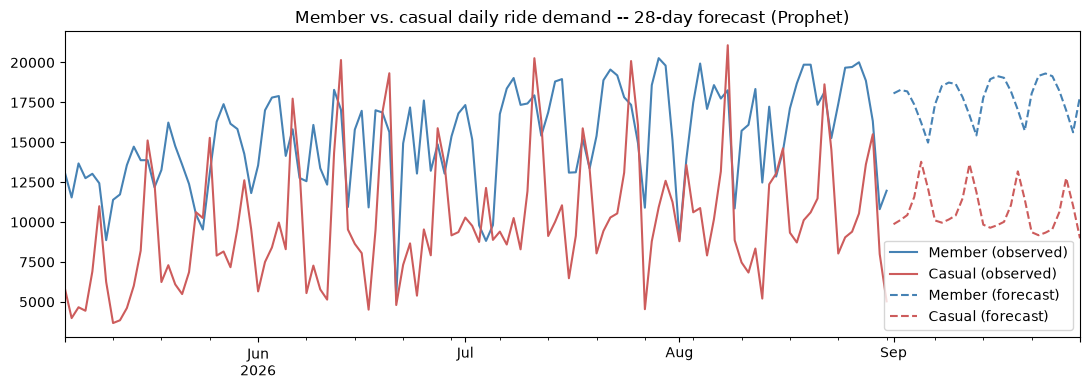

,member_forecast,casual_forecast
2026-09-01,18062.058778,9864.692079
2026-09-02,18278.397445,10124.835581
2026-09-03,18187.648086,10440.146037
2026-09-04,17367.965000,11573.767648
2026-09-05,16238.608369,13778.966680


In [12]:
def forecast_segment(series, periods, model_name):
    idx = pd.date_range(series.index.max() + pd.Timedelta(days=1), periods=periods, freq="D")
    if model_name == "SARIMAX":
        fit = SARIMAX(
            series, order=(1, 1, 1), seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        mean = pd.Series(fit.get_forecast(steps=periods).predicted_mean.values, index=idx).clip(lower=0)
    else:  # Prophet (default when a baseline wins, since baselines don't generalize to segments)
        seg_train = series.reset_index().rename(columns={series.index.name or "index": "ds", series.name: "y"})
        seg_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False,
                             interval_width=CONFIDENCE_LEVEL).fit(seg_train)
        seg_fc = seg_model.predict(seg_model.make_future_dataframe(periods=periods, freq="D")).tail(periods)
        mean = pd.Series(seg_fc["yhat"].values, index=idx)
    return mean.clip(lower=0)

segment_model = best_model_name if best_model_name in ("SARIMAX", "Prophet") else "Prophet"
member_forecast = forecast_segment(segments["member"], FORECAST_HORIZON_DAYS, segment_model)
casual_forecast = forecast_segment(segments["casual"], FORECAST_HORIZON_DAYS, segment_model)

fig, ax = plt.subplots(figsize=(11, 4))
segments["member"].tail(120).plot(ax=ax, label="Member (observed)", color="steelblue")
segments["casual"].tail(120).plot(ax=ax, label="Casual (observed)", color="indianred")
member_forecast.plot(ax=ax, label="Member (forecast)", linestyle="--", color="steelblue")
casual_forecast.plot(ax=ax, label="Casual (forecast)", linestyle="--", color="indianred")
ax.legend()
ax.set_title(f"Member vs. casual daily ride demand -- {FORECAST_HORIZON_DAYS}-day forecast ({segment_model})")
plt.tight_layout()
savefig("05_segment_forecast.png")
plt.show()

segment_forecast_table = pd.DataFrame({"member_forecast": member_forecast, "casual_forecast": casual_forecast})
segment_forecast_table.head()

### Forecast Report

Compiles everything computed across the notebook — the holdout comparison table, the chosen
model, the system-wide forecast, and the segment-level forecast — into a single `report`
dictionary, then persists it to disk in three complementary formats: a human-readable Markdown
summary (mirroring the report pattern from `04_data_quality_assessment.ipynb`), a full-detail
JSON file for another script or pipeline to consume, and a flattened CSV ready to feed a
spreadsheet or BI tool like Power BI. Producing all three from the same underlying data
guarantees the numbers stay in sync across every format.

**Skills demonstrated:** automated end-to-end reporting, multi-format data export for different
audiences, single-source-of-truth reporting design.


In [13]:
report = {
    "run_timestamp_utc": RUN_TIMESTAMP,
    "series_range": {"start": str(system.index.min().date()), "end": str(system.index.max().date())},
    "test_horizon_days": TEST_HORIZON_DAYS,
    "forecast_horizon_days": FORECAST_HORIZON_DAYS,
    "holdout_comparison": comparison.to_dict(orient="index"),
    "best_model": best_model_name,
    "confidence_level": CONFIDENCE_LEVEL,
    "system_forecast": forecast_table.reset_index().rename(
        columns={"index": "date"}).assign(
        date=lambda d: d["date"].astype(str)).to_dict(orient="records"),
    "segment_model": segment_model,
    "segment_forecast": segment_forecast_table.reset_index().rename(
        columns={"index": "date"}).assign(
        date=lambda d: d["date"].astype(str)).to_dict(orient="records"),
}

md_lines = [
    "# Divvy Demand Forecast Report",
    f"**Run timestamp (UTC):** {RUN_TIMESTAMP}  ",
    f"**Series range:** {report['series_range']['start']} -> {report['series_range']['end']}  ",
    f"**Best model ({TEST_HORIZON_DAYS}-day holdout):** {best_model_name}\n",
    "## Holdout Comparison",
    comparison.to_markdown(),
    f"\n## {FORECAST_HORIZON_DAYS}-Day System-Wide Forecast (first 7 days)",
    forecast_table.head(7).to_markdown(),
    f"\n## {FORECAST_HORIZON_DAYS}-Day Segment Forecast (first 7 days, model: {segment_model})",
    segment_forecast_table.head(7).to_markdown(),
]
report_md = "\n\n".join(md_lines)

md_path = os.path.join(REPORTS_FOLDER, "demand_forecast_report.md")
json_path = os.path.join(REPORTS_FOLDER, "demand_forecast_report.json")
csv_path = os.path.join(REPORTS_FOLDER, "demand_forecast.csv")

with open(md_path, "w", encoding="utf-8") as fh:
    fh.write(report_md)
with open(json_path, "w", encoding="utf-8") as fh:
    json.dump(report, fh, indent=2, default=str)
forecast_table.join(segment_forecast_table).reset_index().rename(columns={"index": "date"}).to_csv(csv_path, index=False)

print(f"Markdown report : {md_path}")
print(f"JSON report     : {json_path}")
print(f"CSV forecast    : {csv_path}")
print(f"Charts          : {REPORTS_FOLDER}")

Markdown report : C:\Projects\comprehensive_divvy_bike_sharing_analytics\reports\demand_forecasting_reports\demand_forecast_report.md
JSON report     : C:\Projects\comprehensive_divvy_bike_sharing_analytics\reports\demand_forecasting_reports\demand_forecast_report.json
CSV forecast    : C:\Projects\comprehensive_divvy_bike_sharing_analytics\reports\demand_forecasting_reports\demand_forecast.csv
Charts          : C:\Projects\comprehensive_divvy_bike_sharing_analytics\reports\demand_forecasting_reports


### Summary

This notebook closes the CRISP-DM **Modeling** phase: it benchmarked two naive baselines against
SARIMAX and Prophet on a held-out window, selected the stronger model by RMSE/MAE/MAPE, and used
it to produce both a system-wide and a member/casual demand forecast with uncertainty intervals.

Interpretation notes: MAPE is unstable on near-zero-demand days (e.g. deep winter), so weight MAE
and RMSE more heavily when the series has a strong seasonal trough. A widening forecast interval
over the horizon is expected and reflects growing uncertainty, not a modeling error. The
member/casual split should be read alongside notebook 05's seasonality findings -- casual demand
is far more weather/weekend-sensitive, so its forecast will carry a wider interval than member
demand.

Next steps (CRISP-DM Evaluation / Deployment):
- Re-run this notebook after every ETL load (`03_etl_pipeline.ipynb`) to track
  whether forecast accuracy holds as more months are loaded, and to extend Prophet's yearly
  seasonality estimate once 2+ years of history are available.
- If the business question shifts from *how many rides* to *who will ride* (e.g. predicting
  membership conversion), that's a separate classification notebook on `fact_trip`/`dim_member_type`
  rather than a change to this one.
- For deployment, the CSV/JSON outputs here are already shaped to feed a Power BI forecast page
  or a scheduled job that re-scores the model and alerts on demand spikes above the operational
  capacity used for bike rebalancing.

**Why this matters:** this closing section is the difference between
"I fit a model" and "I built a forecasting process someone else could operate." Calling out where
the metrics are unreliable (MAPE near zero demand), explaining why growing uncertainty is
expected rather than a flaw, and laying out concrete next steps for re-running and deploying the
model are exactly the kind of judgment expected of someone responsible for a forecast that a
business actually acts on.

**Skills demonstrated:** critical interpretation of model metrics and their limitations,
forward-looking deployment/MLOps thinking, translating a completed analysis into a concrete
operational plan.
